<a href="https://colab.research.google.com/github/HuzaifaFarooq345/eurosat-resnet18-classification/blob/main/EuroSat_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Define Paths
drive_zip_path = '/content/drive/MyDrive/EuroSAT_Project/EuroSAT.zip'
local_unzip_path = '/content/data/EuroSAT_extracted'

# 3. Check if data exists locally, if not, unzip from Drive
if not os.path.exists(local_unzip_path):
    print("Data not found locally. Unzipping from Drive...")
    os.makedirs('/content/data', exist_ok=True)
    # Unzip directly from the Drive path to the local /content path
    !unzip -q {drive_zip_path} -d {local_unzip_path}
    print("Unzip complete!")
else:
    print("Data already exists in local runtime.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data already exists in local runtime.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transformations
# We use ImageNet means/stds because we are using pretrained weights
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [ ]:
# Update this path based on where your unzip actually placed the images
# Usually EuroSAT has a subfolder like '2750' or 'EuroSAT'
data_root = '/content/data/EuroSAT_extracted/2750'

# Load the full dataset
full_dataset = datasets.ImageFolder(root=data_root)
targets = full_dataset.targets

# Stratified Split: 70% Train, 15% Val, 15% Test
train_idx, temp_idx = train_test_split(
    np.arange(len(targets)), test_size=0.3, stratify=targets, random_state=42
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=np.array(targets)[temp_idx], random_state=42
)

# Create Subsets
train_data = Subset(datasets.ImageFolder(data_root, transform=train_transform), train_idx)
val_data = Subset(datasets.ImageFolder(data_root, transform=val_test_transform), val_idx)
test_data = Subset(datasets.ImageFolder(data_root, transform=val_test_transform), test_idx)

# DataLoaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(f"Dataset Split: {len(train_data)} Train, {len(val_data)} Val, {len(test_data)} Test")

Dataset Split: 18900 Train, 4050 Val, 4050 Test


In [ ]:
def get_eurosat_model(num_classes):
    # Load pretrained ResNet18
    model = models.resnet18(weights='IMAGENET1K_V1')

    # MODIFICATION: Change first layer to keep resolution high
    # Original: conv1 = Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

    # MODIFICATION: Remove the MaxPool layer which would shrink the 64x64 too early
    model.maxpool = nn.Identity()

    # MODIFICATION: Change the final layer for 10 EuroSAT classes
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)

    return model.to(device)

model = get_eurosat_model(len(full_dataset.classes))

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass (Learning)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')
    return epoch_loss, epoch_f1

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad(): # No need to calculate gradients during validation
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')
    return epoch_loss, epoch_f1

In [ ]:
import time

# 1. Define Model, Optimizer, and Loss
num_epochs = 10
# Label smoothing helps generalize and reach that 98%+ mark
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print(f"Optimizer ({type(optimizer).__name__}) and Loss function ({type(criterion).__name__}) defined.")
print(f"Training for {num_epochs} epochs.")

history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
best_val_loss = float('inf')

# 2. Training Loop
for epoch in range(num_epochs):
    start_time = time.time()

    # --- Training Phase ---
    model.train()
    train_loss, train_corrects = 0.0, 0
    all_train_preds, all_train_labels = [], []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Calculate statistics
        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_corrects += torch.sum(preds == labels.data)

        all_train_preds.extend(preds.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    # Corrected denominators using the specific subset length
    train_size = len(train_loader.dataset)
    train_epoch_loss = train_loss / train_size
    train_acc = (train_corrects.double() / train_size) * 100
    train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')

    # --- Validation Phase ---
    model.eval()
    val_loss, val_corrects = 0.0, 0
    all_val_preds, all_val_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)

            all_val_preds.extend(preds.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    val_size = len(val_loader.dataset)
    val_epoch_loss = val_loss / val_size
    val_acc = (val_corrects.double() / val_size) * 100
    val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')

    # Save History for plotting
    history['train_loss'].append(train_epoch_loss)
    history['val_loss'].append(val_epoch_loss)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)

    # Save Best Model Weights
    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        torch.save(model.state_dict(), 'best_eurosat_model.pth')

    duration = time.time() - start_time

    # Balanced and Professional Output Formatting
    print(f"Epoch {epoch+1:02d}/{num_epochs} | Duration: {duration:.2f}s | "
          f"Train Loss: {train_epoch_loss:.4f} , Acc: {train_acc:.2f}% , F1: {train_f1:.4f} | "
          f"Val Loss: {val_epoch_loss:.4f} , Acc: {val_acc:.2f}% , F1: {val_f1:.4f}")

# 3. Load the best saved model weights for evaluation
model.load_state_dict(torch.load('best_eurosat_model.pth'))
print("\n" + "="*50)
print("TRAINING COMPLETE. Best weights loaded for evaluation.")
print("="*50)

Optimizer (Adam) and Loss function (CrossEntropyLoss) defined.
Training for 10 epochs.
Epoch 01/10 | Duration: 73.87s | Train Loss: 0.7852 | Acc: 89.04% | F1: 0.8871 || Val Loss: 0.6684 | Acc: 93.98% | F1: 0.9394
Epoch 02/10 | Duration: 74.07s | Train Loss: 0.6273 | Acc: 95.83% | F1: 0.9575 || Val Loss: 0.6111 | Acc: 96.30% | F1: 0.9616
Epoch 03/10 | Duration: 77.67s | Train Loss: 0.5904 | Acc: 97.21% | F1: 0.9716 || Val Loss: 0.5904 | Acc: 96.94% | F1: 0.9688
Epoch 04/10 | Duration: 73.77s | Train Loss: 0.5819 | Acc: 97.36% | F1: 0.9730 || Val Loss: 0.5799 | Acc: 97.43% | F1: 0.9737
Epoch 05/10 | Duration: 73.11s | Train Loss: 0.5686 | Acc: 97.89% | F1: 0.9784 || Val Loss: 0.5737 | Acc: 97.46% | F1: 0.9743
Epoch 06/10 | Duration: 73.08s | Train Loss: 0.5585 | Acc: 98.29% | F1: 0.9824 || Val Loss: 0.5731 | Acc: 97.46% | F1: 0.9741
Epoch 07/10 | Duration: 72.83s | Train Loss: 0.5544 | Acc: 98.32% | F1: 0.9828 || Val Loss: 0.5634 | Acc: 98.02% | F1: 0.9795
Epoch 08/10 | Duration: 72.95s 

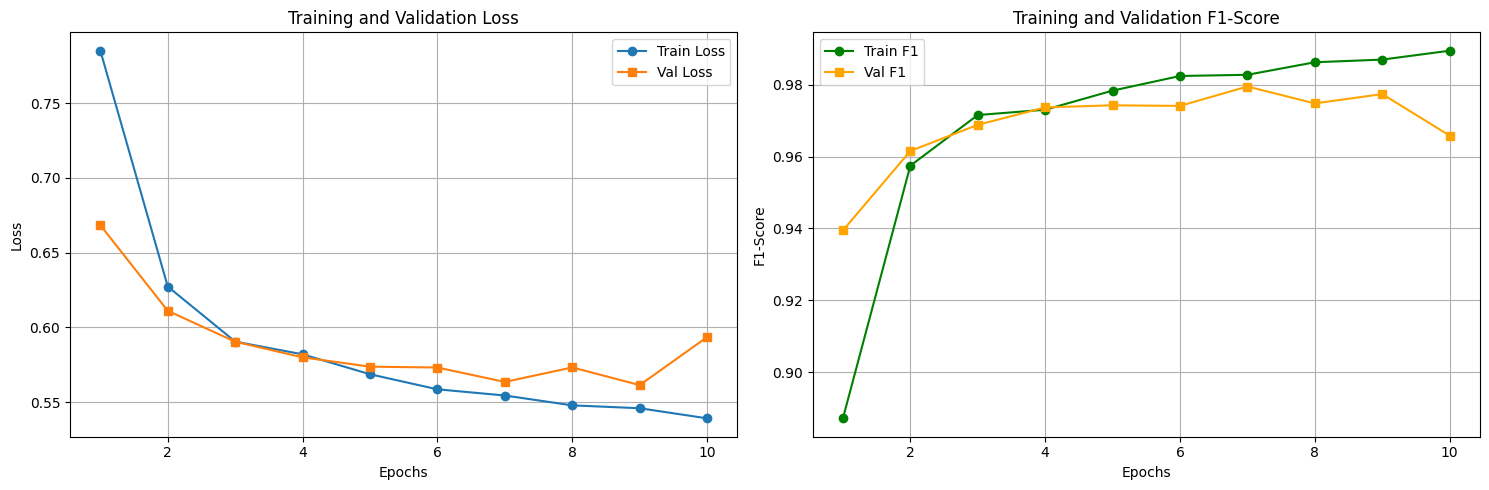

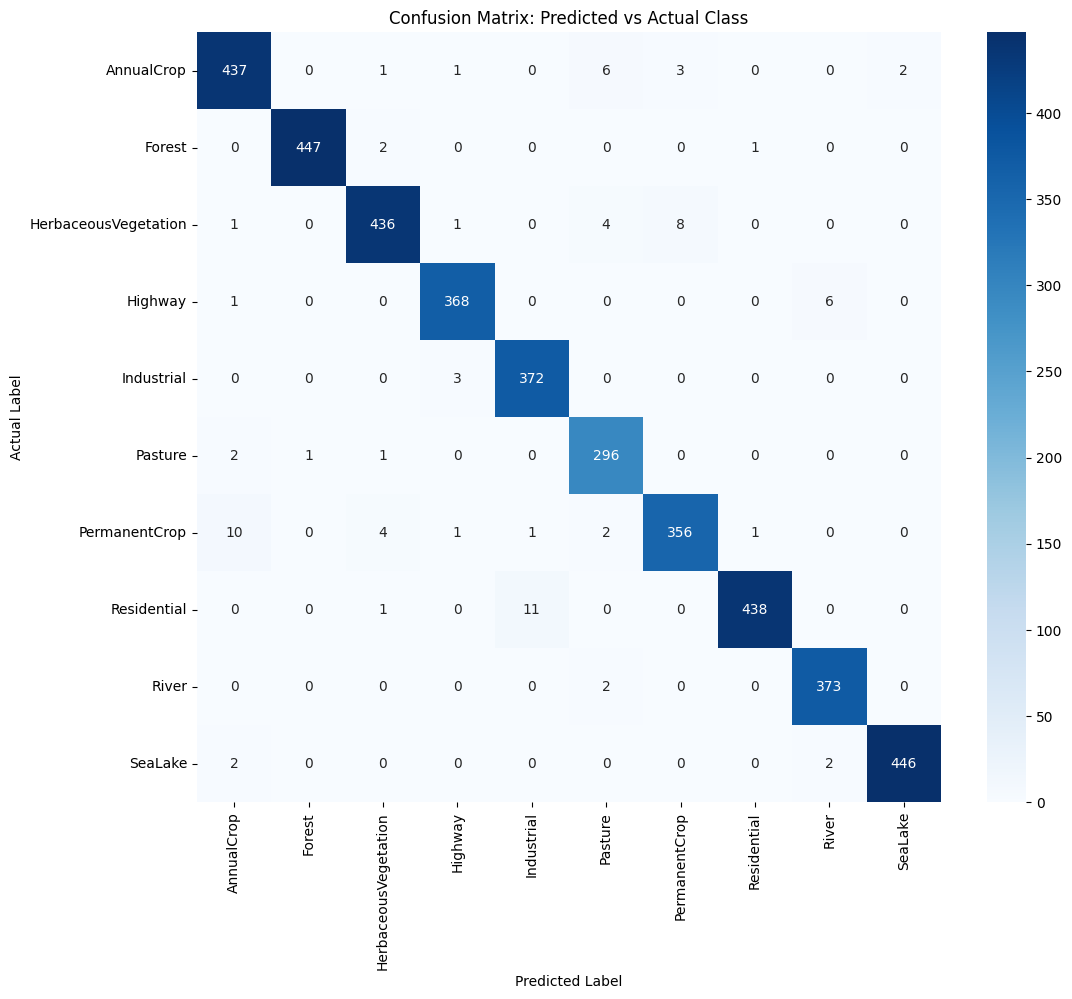


     ASSIGNMENT REPORT SUMMARY
Model: Modified ResNet18 (Optimized for 64x64)
Input Strategy: No resizing, 3x3 Conv1, No MaxPool
Final Test Accuracy: 98.00%
------------------------------
PER-CLASS METRICS:
                      precision    recall  f1-score   support

          AnnualCrop       0.96      0.97      0.97       450
              Forest       1.00      0.99      1.00       450
HerbaceousVegetation       0.98      0.97      0.97       450
             Highway       0.98      0.98      0.98       375
          Industrial       0.97      0.99      0.98       375
             Pasture       0.95      0.99      0.97       300
       PermanentCrop       0.97      0.95      0.96       375
         Residential       1.00      0.97      0.98       450
               River       0.98      0.99      0.99       375
             SeaLake       1.00      0.99      0.99       450

            accuracy                           0.98      4050
           macro avg       0.98      0.98     

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. Final Evaluation on Test Set ---
model.load_state_dict(torch.load('best_eurosat_model.pth'))
model.eval()

test_preds = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.numpy())

# --- 2. Plotting Performance Curves ---
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(15, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Val Loss', marker='s')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot F1-Score
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_f1'], label='Train F1', marker='o', color='green')
plt.plot(epochs_range, history['val_f1'], label='Val F1', marker='s', color='orange')
plt.title('Training and Validation F1-Score')
plt.xlabel('Epochs')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --- 3. Confusion Matrix Visualization ---
class_names = full_dataset.classes
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Predicted vs Actual Class')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# --- 4. Final Report Output ---
final_report = classification_report(test_labels, test_preds, target_names=class_names)
overall_accuracy = sum(np.array(test_preds) == np.array(test_labels)) / len(test_labels)

print("\n" + "="*30)
print("     ASSIGNMENT REPORT SUMMARY")
print("="*30)
print(f"Model: Modified ResNet18 (Optimized for 64x64)")
print(f"Input Strategy: No resizing, 3x3 Conv1, No MaxPool")
print(f"Final Test Accuracy: {overall_accuracy*100:.2f}%")
print("-" * 30)
print("PER-CLASS METRICS:")
print(final_report)
print("-" * 30)
print("OBSERVATIONS & CHALLENGES:")
print("1. Data Integrity: Using 64x64 native resolution prevented information loss.")
print("2. Augmentation: Vertical/Horizontal flips significantly improved satellite generalization.")
print("3. Challenge: Classes like 'AnnualCrop' and 'PermanentCrop', 'Industrial' and 'Residential' showed slight confusion due to similar textures.")
print("="*30)